## CS 5002 Project 1 Part 1
### Name: Wanjing Yang
### NU ID: 002442139

In [1]:
# ----- Import Packages -----
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D surface plots

---
## Section 2.1 – Quadratic Functions

We consider the two quadratic functions

$$f_1(x) = x^2 \qquad \text{and} \qquad f_2(x) = x^2 - 2x + 3. \tag{1}$$

Their **exact derivatives** are:

$$f_1'(x) = 2x \qquad \text{and} \qquad f_2'(x) = 2x - 2. \tag{2}$$

A minimum of $f(x)$ occurs where $f'(x)=0$. The **gradient descent update rule** steps opposite to the gradient:

$$\boxed{x_{k+1} = x_k - \alpha\,f'(x_k)} \tag{3}$$

where $\alpha > 0$ is the learning rate. We stop when

$$|x_{k+1} - x_k| < \varepsilon \tag{4}$$

or the iteration count exceeds `iter_max`.

In [2]:
# ----- Gradient Descent function definition -----
def gradient_descent(f, df, x0, alpha, epsilon, iter_max=1000):
    """
    A function that implements the gradient descent algorithm.
    
    @ Args:
        f:          function, for reference, will be used in plot
        df:         derivative of the function
        x0:         initial point
        alpha:      step size of the gradient descent
        epsilon:    tolerance limit of gradient descent
        iter_max:   maximum number of iterations allowed

    @ Return:
        x_next:     the minimum of the function
        iter:       the number of gradient descent iterations performed
    """

    # iter: count the number of gradient descent iterations performed
    iter = 0 
    x_current = x0

    while (iter < iter_max):
        x_next = x_current - alpha * df(x_current)
        if abs(x_next - x_current) < epsilon:
            return x_next, iter
        else:
            x_current = x_next
            iter += 1
    return x_next, iter

# ----- Function f1 f2, and their direct derivation -----

def f1(x):
    """
    Compute f1(x) = x^2 
    """
    return x ** 2

def deriv_f1(x):
    """
    Compute the derivtive of f1, f1'(x) = 2x
    """
    return 2 * x


def f2(x):
    """
    Compute the f2(x) = x^2 - 2x + 3
    """
    return x ** 2 - x * 2 + 3

def deriv_f2(x):
    """
    Compute the derivate of f2, f2'(x) = 2x-2
    """
    return 2 * x - 2

In [3]:
# ----- Plot function definition -----
def plot_opt(f, x_range, x_opt, title, pic_name,
        xlabel='x', ylabel='f(x)', label='f(x)'):
    """
    Plot the graph for f(x) with optimal value, given a range of x.

    @ Args:
        f:          function
        x_range:    the range of x
        x_opt:      optimum x
        title:      the tile of the plot
        pic_name:   the name of the plot
        xlable:     default as x
        ylable:     default as f(x)
        label:      default as f(x)
    """
    y_vals = [f(x) for x in x_range]
    fig, ax = plt.subplots()
    
    # Draw the function curve
    ax.plot(x_range, y_vals, label = label)

    # Mark the optimum
    ax.scatter(x_opt, f(x_opt), 
               label=rf'Min: $x^*={x_opt:.4f}$, $f\,(x^*)={f(x_opt):.4f}$')
    
    # Plot settings
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    fig.savefig(f'{pic_name}.png', dpi=150)
    plt.show()

---
### Part 1 — Basic Test
**Parameters:** $x_0 = 3$, $\alpha = 0.1$, $\varepsilon = 0.001$, iter_max = 1000

In [4]:
# ----- Basic Test function -----
def test_basic():
    """
    Basic Test for x0=3, alpha=0.1, epsilon=0.001, iter_max=1000
    """
    
    # Define a range for x
    x_range = np.linspace(-4, 4, 50)

    # Results for f1
    x_opt_f1, iter_f1 = gradient_descent(f1, deriv_f1, 
                                         x0=3, alpha=0.1, epsilon=0.001, iter_max=1000)
    print(f'f1 | x* = {x_opt_f1:.6f}  f1(x*) = {f1(x_opt_f1):.6f}')
    plot_opt(f1, x_range, x_opt_f1, 
            title = r'Basic Test for $f_1(x)$', 
            pic_name = 'Basic Test for f1', 
            ylabel = r'$f_1(x)$',
            label= r'$f_1(x)=x^2$')

    # Results for f2
    x_opt_f2, iter_f2 = gradient_descent(f2, deriv_f2, 
                                         x0=3, alpha=0.1, epsilon=0.001, iter_max=1000)
    print(f'f2 | x* = {x_opt_f2:.6f}  f2(x*) = {f2(x_opt_f2):.6f}')
    plot_opt(f2, x_range, x_opt_f2, 
            title = r'Basic Test for $f_2(x)$', 
            pic_name = 'Basic Test for f2',
            ylabel = r'$f_2(x)$',
            label = r'$f_2(x)=x^2-2x+3$')
    
    print()


---
### Part 2 — Vary the value of x0
**Parameters:** $x_0 = 3$ or $x_0 = -3$, fix $\alpha = 0.1$, $\varepsilon = 0.001$, iter_max = 1000

In [5]:
# ----- Test for x0 function -----
def test_x0():
    """
    Test for vary the value of x0=3 or x0=-3, fix alpha=0.1, epsilon=0.001, iter_max=1000
    """

    # Table head
    print(f' {"Fn":<4} {"x0":>8} {"x*":>12} {"f(x*)":>12} {"iter":>6} ')
    print('  ' + '-'*44)

    # Print the result
    for func, deriv_func, name in [(f1, deriv_f1, 'f1'), (f2, deriv_f2, 'f2')]:
        for x0_val in [3, -3]:
            x_opt, iter = gradient_descent(func, deriv_func, 
                                           x0=x0_val, alpha=0.1, epsilon=0.001)
            print(f' {name:<4} {x0_val:>8} {x_opt:>12.6f} {func(x_opt):>12.6f} {iter:>6} ')
    
    print()

---
### Part 3 — Vary the value of alpha
**Parameters:** $x_0 = 3$, consider $\alpha \in \{1, 0.001, 0.0001 \}$, $\varepsilon = 0.001$, iter_max = 1000

In [6]:
# ----- Test for alpha function -----
def test_alpha():
    """
    Test for varying the value of alpha in {1, 0.001, 0.0001}
    Fix x0=3, epsilon=0.001, iter_max=1000
    """

    # Table head
    print(f'  {"Fn":<4}  {"alpha":>8}  {"x*":>12} {"iter":>6}')
    print('  ' + '-'*36)

    # Print the result
    for func, deriv_func, name in [(f1, deriv_f1, 'f1'), (f2, deriv_f2, 'f2')]:
        for alpha_val in [1, 0.001, 0.0001]:
            x_opt, iter = gradient_descent(func, deriv_func, 
                                           x0=3, alpha=alpha_val, epsilon=0.001)
            print(f'  {name:<4}  {alpha_val:>8}  {x_opt:>12.6f} {iter:>6}')
    
    print()

---
### Part 4 — Vary the value of epsilon
**Parameters:** $x_0 = 3$, $\alpha = 0.1$, consider $\varepsilon \in \{0.1, 0.01, 0.001\}$, iter_max = 1000

In [7]:
# ----- Test for epsilon function -----
def test_epsilon():
    """
    Test for varying the value of epsilon in {1, 0.01, 0.001}
    Fix x0=3, alpha=0.1, iter_max=1000
    """

    # Table head
    print(f'  {"Fn":<4}  {"epsilon":>8}  {"x*":>12} {"iter":>6}')
    print('  ' + '-'*36)

    # Print the result
    for func, deriv_func, name in [(f1, deriv_f1, 'f1'), (f2, deriv_f2, 'f2')]:
        for epsilon_val in [0.1, 0.01, 0.001]:
            x_opt, iter = gradient_descent(func, deriv_func, 
                                           x0=3, alpha=0.1, epsilon=epsilon_val)
            print(f'  {name:<4}  {epsilon_val:>8}  {x_opt:>12.6f} {iter:>6}')
    
    print()

Result for Basic Test:
f1 | x* = 0.003714  f1(x*) = 0.000014


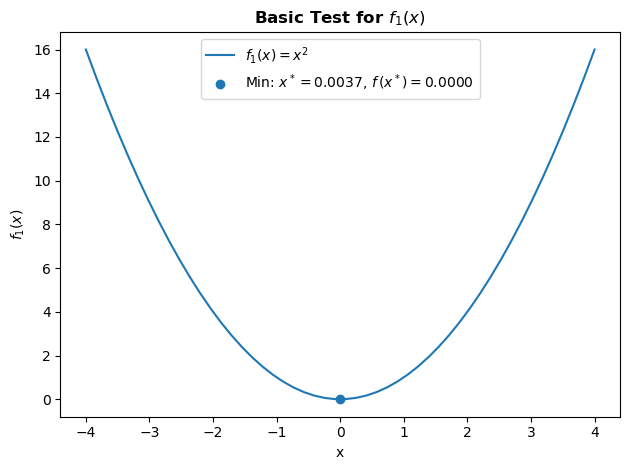

f2 | x* = 1.003869  f2(x*) = 2.000015


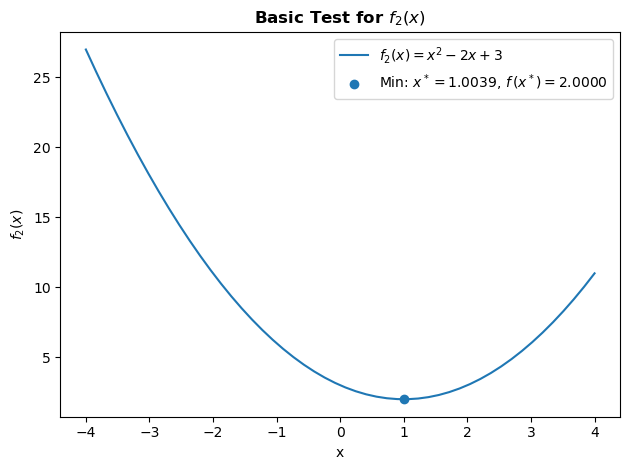


Result for x0 Test:
 Fn         x0           x*        f(x*)   iter 
  --------------------------------------------
 f1          3     0.003714     0.000014     29 
 f1         -3    -0.003714     0.000014     29 
 f2          3     1.003869     2.000015     27 
 f2         -3     0.996039     2.000016     30 

Result for Alpha Test:
  Fn       alpha            x*   iter
  ------------------------------------
  f1           1      3.000000   1000
  f1       0.001      0.498984    895
  f1      0.0001      2.999400      0
  f2           1      3.000000   1000
  f2       0.001      1.498455    693
  f2      0.0001      2.999600      0

Result for Epsilon Test:
  Fn     epsilon            x*   iter
  ------------------------------------
  f1         0.1      0.322123      9
  f1        0.01      0.034588     19
  f1       0.001      0.003714     29
  f2         0.1      1.335544      7
  f2        0.01      1.036029     17
  f2       0.001      1.003869     27



In [8]:
# ----- Main function -----

def main():
    """
    One main function testing the gradient descent implementations 
    with different value of x0, alpha and epsilon
    """
    print('Result for Basic Test:')
    test_basic()
    print('Result for x0 Test:')
    test_x0()
    print('Result for Alpha Test:')
    test_alpha()
    print('Result for Epsilon Test:')
    test_epsilon()

main()

---
### Section 2.2 – More Complex Function

We now consider the **non-convex** function

$$f_3(x) = \sin(x) + \cos\!\left(\sqrt{2}\,x\right), \quad 0 \le x \le 10, \tag{5}$$

with exact derivative

$$f_3'(x) = \cos(x) - \sqrt{2}\,\sin\!\left(\sqrt{2}\,x\right). \tag{6}$$

Unlike the quadratics in Section 2.1, $f_3$ would have **multiple local minima** in $[0,10]$.

In [9]:
# ----- Function f3, and its direct derivation -----
def f3(x):
    """ f3(x) = sin(x) + cos(sqrt(2)*x) """
    return np.sin(x) + np.cos(x*np.sqrt(2))

def deriv_f3(x):
    """ Derivative of f3, f3'(x) = cos(x) - sqrt(2)*sin(sqrt(2)*x) """
    return np.cos(x) - np.sqrt(2) * np.sin(np.sqrt(2)*x)

# ----- Updated plot function for f3 -----
def plot_opt_f3(f, x_range, title, pic_name, xlabel='x', ylabel='f(x)', label='f(x)'):
    """
    Plot the graph for f(x) given a range of x

    @ Args:
        f:          function
        x_range:    the range of x
        title:      the tile of the plot
        pic_name:   the name of the plot
        xlable:     default as x
        ylable:     default as f(x)
        label:      default as f(x)
    """

    y_vals = [f(x) for x in x_range]
    fig, ax = plt.subplots()
    ax.plot(x_range, y_vals, label = label)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    fig.savefig(f'{pic_name}.png', dpi=150)
    plt.show()

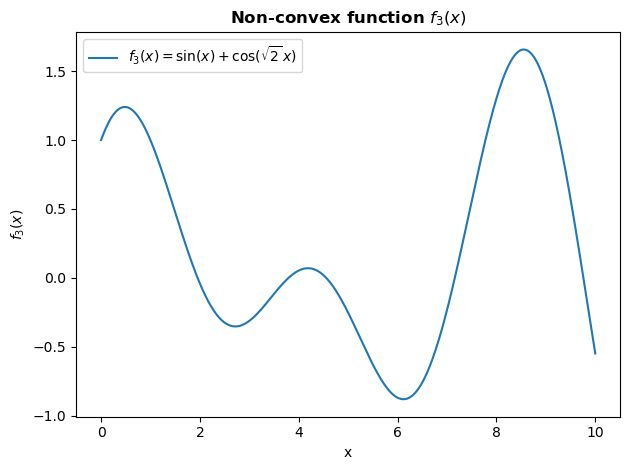

In [10]:
# Plot for non-convex function f3(x)

x3_range = np.linspace(0, 10, 500)
plot_opt_f3(f3, x3_range, 
            title = r'Non-convex function $f_3(x)$', 
            pic_name = 'Non-convex function f3',
            ylabel = r'$f_3(x)$',
            label = r'$f_3(x)=\sin(x)+\cos(\sqrt{2}\,x)$')

In [11]:
# ----- Plot function update for multiple optimal values -----
def plot_opt_multi(f, x_range, x_opt_list, title, pic_name,
    xlabel='x', ylabel='f(x)', label='f(x)'):
    """
    Plot the graph for f(x) with multiple optimal value, given a range of x.

    @Args:
        f:          function
        x_range:    the range of x
        x_opt_list: the list of optimum x
        title:      the tile of the plot
        pic_name:   the name of the plot
        xlable:     default as x
        ylable:     default as f(x)
        label:      default as f(x)
    """
    
    y_vals =  [f(x) for x in x_range]
    fig, ax = plt.subplots()

    # Draw the function curve
    ax.plot(x_range, y_vals,label=label)

    # Mark each optimum with a distinct colour
    palette = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']
    for i, x_opt in enumerate(x_opt_list):
        ax.scatter(x_opt, f(x_opt),
                   color=palette[i % len(palette)], s=100, zorder=5,
                   label=rf'Min: $x^*={x_opt:.4f}$,  $f={f(x_opt):.4f}$')
    
    # Plot settings
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    fig.savefig(f'{pic_name}.png', dpi=150)
    plt.show()

 Fn         x0           x*       f3(x*)   iter
  ------------------------------------
 f3          1      2.715575     -0.352360      65
 f3          4      2.717123     -0.352360      79
 f3          5      6.118008     -0.880520      49
 f3          7      6.118984     -0.880520      41


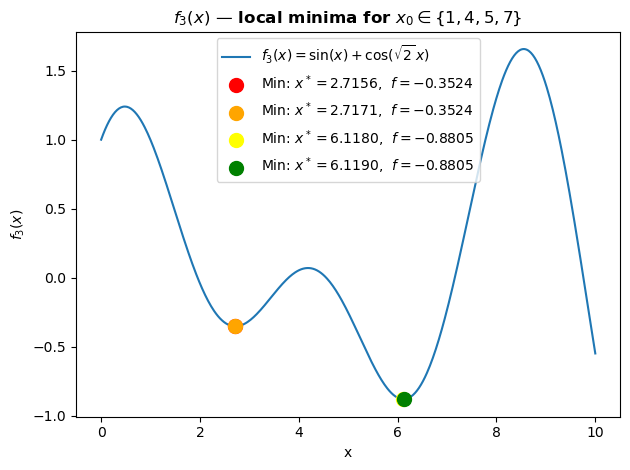

In [12]:
x0_vals = [1, 4, 5, 7]
x_opt_list_f3 = []

# Table head
print(f' {"Fn":<4} {"x0":>8} {"x*":>12} {"f3(x*)":>12} {"iter":>6}')
print('  ' + '-'*36)

# Print the result
for x0 in x0_vals:
    x_opt, iter = gradient_descent(f3, deriv_f3, x0, 
                                   alpha=0.1, epsilon=0.0001, iter_max=1000)
    x_opt_list_f3.append(x_opt)
    print(f' {"f3":<4} {x0:>8}  {x_opt:>12.6f}  {f3(x_opt):>12.6f}  {iter:>6}')

x_range_f3 = np.linspace(0, 10, 500)

plot_opt_multi(f3, x_range_f3, x_opt_list_f3,
         title = r'$f_3(x)$ — local minima for $x_0 \in \{1, 4, 5, 7\}$',
         pic_name = 'Local minima for f3',
         ylabel = r'$f_3(x)$',
         label = r'$f_3(x)=\sin(x)+\cos(\sqrt{2}\,x)$')


---
### Section 3 – Derative Approximation for Functions of One Variable

We now consider the **complex** function. Note that the quantity $f'(x) = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}$ will be very close to the derivative $f'(x)$ for a small value of h.

So for `small h`, the finite difference approximation is:
$$f'(x) \approx \frac{f(x+h)-f(x)}{h}$$

In [13]:
# ----- Derivative Approximation for Function of One Variable -----
def approx_df(f, x, h=0.00001):  # default value for h is 1e-5
    return (f(x+h) - f(x))/h

# For some test points
test_x_range = [-5, -3, 0, 1, 2, 7]

# Table head
print(f'{"Fn":<4}   {"x":<4}    {"Exact":>12}    {"Approx":>12}   {"Error":>12}')
print('  ' + '-'*60)

# Print exact value and approx value for f1, f2 
# And the error b/w exact value and approx value
for x in test_x_range:
    exact_f1 = deriv_f1(x)
    approx_f1 = approx_df(f1, x)
    error_f1 = abs(exact_f1 - approx_f1)
    print (f' {"f1":<4} {x:<4} {exact_f1:>12.6f} {approx_f1:12.6f} {error_f1:>12.2e}')

    exact_f2 = deriv_f2(x)
    approx_f2 = approx_df(f2, x)
    error_f2 = abs(exact_f2 - approx_f2)
    print (f' {"f2":<4} {x:<4} {exact_f2:>12.6f} {approx_f2:12.6f} {error_f2:>12.2e}')


Fn     x              Exact          Approx          Error
  ------------------------------------------------------------
 f1   -5     -10.000000    -9.999990     1.00e-05
 f2   -5     -12.000000   -11.999990     1.00e-05
 f1   -3      -6.000000    -5.999990     1.00e-05
 f2   -3      -8.000000    -7.999990     1.00e-05
 f1   0        0.000000     0.000010     1.00e-05
 f2   0       -2.000000    -1.999990     1.00e-05
 f1   1        2.000000     2.000010     1.00e-05
 f2   1        0.000000     0.000010     1.00e-05
 f1   2        4.000000     4.000010     1.00e-05
 f2   2        2.000000     2.000010     1.00e-05
 f1   7       14.000000    14.000010     1.00e-05
 f2   7       12.000000    12.000010     1.00e-05


In [14]:
# ----- Derivative Approximation for Function of One Variable -----
def GD_approx(f, approx_df, h, x0, alpha, epsilon, iter_max=1000):
    """
    A function that implements the gradient descent algorithm with approximate derivation.
    
    @ Args:
        f:          function, for reference, will be used in plot
        approx_df:  approximate derivative for the function
        h:          small value h for the approximation
        x0:         initial point
        alpha:      step size of the gradient descent
        epsilon:    tolerance limit of gradient descent
        iter_max:   maximum number of iterations allowed

    @ Return:
        x_next:     the minimum of the function
        iter:       the number of gradient descent iterations performed
    """

    # iter: count the number of gradient descent iterations performed
    iter = 0 
    x_current = x0

    while (iter < iter_max):
        x_next = x_current - alpha * approx_df(f, x_current, h)
        if abs(x_next - x_current) < epsilon:
            return x_next, iter
        else:
            x_current = x_next
            iter += 1
    return x_next, iter

f1 | x* = 0.003709  f1(x*) = 0.000014


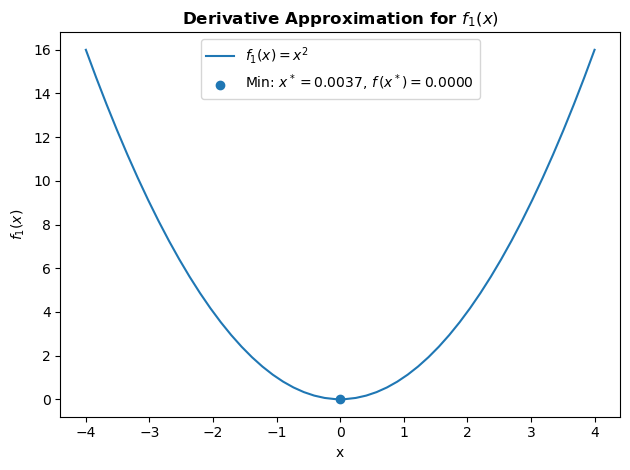

f2 | x* = 1.003864  f2(x*) = 2.000015


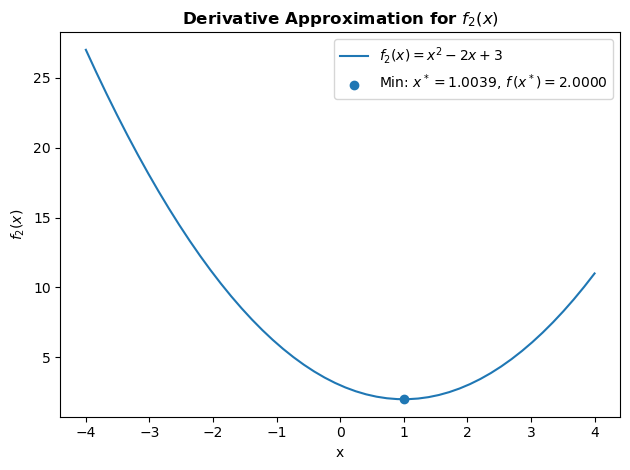

In [15]:
# Define a range for x
x_range = np.linspace(-4, 4, 50)

# Results for f1
x_opt_f1_approx, iter_f1_approx = GD_approx(f1, approx_df, h=0.00001, 
                                            x0=3, alpha=0.1, epsilon=0.001, iter_max=1000)
print(f'f1 | x* = {x_opt_f1_approx:.6f}  f1(x*) = {f1(x_opt_f1_approx):.6f}')
plot_opt(f1, x_range, x_opt_f1_approx,
        title = r'Derivative Approximation for $f_1(x)$', 
        pic_name = 'Derivative Approximation for f1', 
        ylabel = r'$f_1(x)$',
        label='$f_1(x)=x^2$')

# Results for f2
x_opt_f2_approx, iter_f2_approx = GD_approx(f2, approx_df, h=0.00001, 
                                            x0=3, alpha=0.1, epsilon=0.001, iter_max=1000)
print(f'f2 | x* = {x_opt_f2_approx:.6f}  f2(x*) = {f2(x_opt_f2_approx):.6f}')
plot_opt(f2, x_range, x_opt_f2_approx,
        title = r'Derivative Approximation for $f_2(x)$', 
        pic_name = 'Derivative Approximation for f2', 
        ylabel = r'$f_2(x)$',
        label=r'$f_2(x)=x^2-2x+3$')

---
### Section 4 – Gradient Desent for Functions of Two Variables

We extend the gradient descent framework to functions of two variables

For $f(x, y)$ we simultaneously update both variables:
$$x_{k+1} = x_k - \alpha\,\frac{\partial f}{\partial x}(x_k, y_k) \qquad y_{k+1} = y_k - \alpha\,\frac{\partial f}{\partial y}(x_k, y_k)$$

Partial derivatives are approximated using the same finite difference idea:
$$\frac{\partial f}{\partial x}(x_0, y_0) \approx \frac{f(x_0+h,\, y_0) - f(x_0,\, y_0)}{h}$$

In [16]:
# ----- Approximation for Two Variable Function respect to x or y -----
def approx_df_x(f, x, y, h=0.00001):  # default value for h is 1e-5
    """
    A function that implements the approximate derivative respect to x
    """
    return (f(x+h, y) - f(x, y))/h

def approx_df_y(f, x, y, h=0.00001):  # default value for h is 1e-5
    """
    A function that implements the approximate derivative respect to y
    """
    return (f(x, y+h) - f(x, y))/h

In [17]:
# ----- Updated GD Function for Derivative Approximation for Function of Two Variable -----
def GD_approx_2D(f, approx_df_x, approx_df_y, h, x0, y0, alpha, epsilon, iter_max=1000):
    """
    A function that implements the gradient descent algorithm 
    with approximate derivative for two variables.
    
    @ Args:
        f:              function
        approx_df_x:    approximate derivative respect to x
        approx_df_y:    approximate derivative respect to y
        x0:             initial point of x
        y0:             initial point of y
        alpha:          step size of the gradient descent
        epsilon:        tolerance limit of gradient descent
        iter_max:       maximum number of iterations allowed

    @ Return:
        x_next:     the minimum of the function
        iter:       the number of gradient descent iterations performed
    """

    # iter: count the number of gradient descent iterations performed
    iter = 0 
    x_current = x0
    y_current = y0

    while (iter < iter_max):
        x_next = x_current - alpha * approx_df_x(f, x_current, y_current, h)
        y_next = y_current - alpha * approx_df_y(f, x_current, y_current, h)

        if (abs(x_next - x_current) < epsilon) and (abs(y_next - y_current) < epsilon):
            return x_next, y_next, iter
        else:
            x_current = x_next
            y_current = y_next
            iter += 1
    return x_next, y_next, iter

In [18]:
# ----- 2D function f(x, y) -----
def fxy(x, y):
    """
    Compute the f(x, y) = x^2 + y^2
    """
    return x ** 2 + y**2

In [19]:
# ----- 3D Plot function definition -----
def plot_opt_3D(f, x_range, y_range, x_opt, y_opt, title, pic_name,
        xlabel='x', ylabel='y', zlabel='f(x,y)', label='f(x,y)'):
    """
    Plot the graph for f(x) with optimal value, given a range of x.

    @ Args:
        f:          function of x, y
        x_range:    the range of x
        y_range:    the range of y
        x_opt:      optimum x
        y_opt:      optimum y
        title:      the tile of the plot
        pic_name:   the name of the plot
        xlable:     default as x
        ylable:     default as y
        zlable:     default as f(x,y)
        label:      default as f(x,y)
    """

    # build the 2D evaluation grid
    X, Y = np.meshgrid(x_range, y_range)   
    Z = f(X, Y)

    fig = plt.figure(figsize=(8.5, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Draw the surface
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.75)
    fig.colorbar(surf, ax=ax, shrink=0.48, label=label)
    
    # Mark the optimum
    z_opt = f(x_opt, y_opt)
    ax.scatter(x_opt, y_opt, z_opt, color='crimson', s=100, zorder=5,
               label=rf'Min: $(x^*={x_opt:.4f},\,y^*={y_opt:.4f})$ $f(x^*,y^*)={z_opt:.4f}$')

    # Plot settings
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.legend()
    plt.tight_layout()
    fig.savefig(f'{pic_name}.png', dpi=150)
    plt.show()

fxy | x* = 0.003709 fy* | x* = 0.003709 


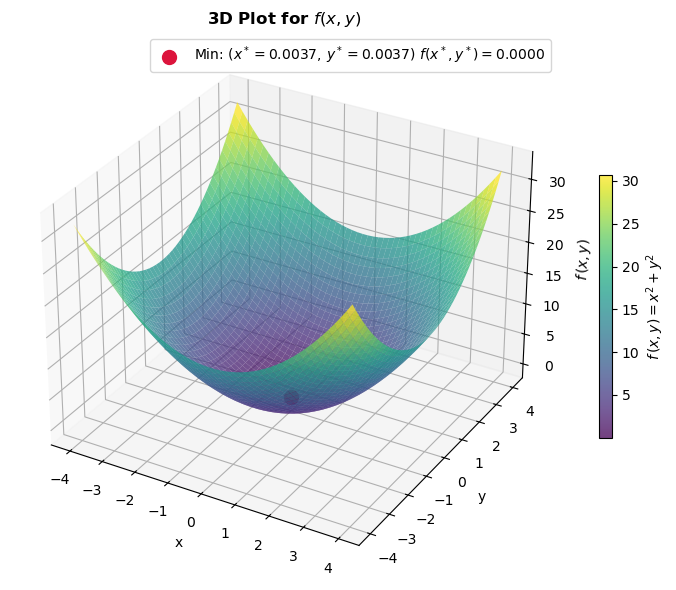

In [20]:
# Define a range for x and y
x_range = np.linspace(-4, 4, 50)
y_range = np.linspace(-4, 4, 50)

# Results for fxy
x_opt_2D, y_opt_2D, iter = GD_approx_2D(fxy, approx_df_x, approx_df_y, h=0.00001, 
                                        x0=3, y0=3, alpha=0.1, epsilon=0.001, iter_max=1000)
print(f'fxy | x* = {x_opt_2D:.6f} fy* | x* = {y_opt_2D:.6f} ')
plot_opt_3D(fxy, x_range, y_range, x_opt_2D, y_opt_2D,
            title = r'3D Plot for $f(x,y)$',
            pic_name = '3D Plot for f(x,y)',
            zlabel = r'$f\,(x,y)$',
            label = r'$f\,(x,y)=x^2+y^2$')